In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
import pandas as pd
def parse_benchmark_log(log_path):
    """从benchmark.log中提取关键metrics"""
    metrics = {}
    try:
        with open(log_path, 'r') as f:
            content = f.read()
        
        # 提取 TTFT (Time To First Token)
        ttft_match = re.search(r'Mean TTFT \(ms\):\s+([\d.]+)', content)
        if ttft_match:
            metrics['ttft'] = float(ttft_match.group(1))
        
        # 提取 TPOT (Time Per Output Token)
        tpot_match = re.search(r'Mean TPOT \(ms\):\s+([\d.]+)', content)
        if tpot_match:
            metrics['tpot'] = float(tpot_match.group(1))
        
        # 提取 Throughput
        thru_match = re.search(r'Output token throughput \(tok/s\):\s+([\d.]+)', content)
        if thru_match:
            metrics['throughput'] = float(thru_match.group(1))
        
        # 确保所有metrics都存在
        if 'ttft' in metrics and 'tpot' in metrics and 'throughput' in metrics:
            return metrics
    except Exception as e:
        print(f"Error parsing {log_path}: {e}")
    return None

def sort_key(pp_config):
    """PP config排序key: 按prefill层数排序"""
    return int(pp_config.split('-')[0])

In [16]:


# ==================== 新数据：两种workload对比 ====================
LOG_DIR_NEW = "/home/bxb1/vllm_workbench/vllm/new-logs/project-config-finder-llama"

def parse_folder_name_full(folder_name):
    """从文件夹名中提取pp config, request rate和workload类型"""
    pp_match = re.search(r'\{pp=(\d+-\d+)\}', folder_name)
    rr_match = re.search(r'\{rr=([\d.]+)\}', folder_name)
    in_match = re.search(r'\{in=(\d+)\}', folder_name)
    out_match = re.search(r'\{out=(\d+)\}', folder_name)
    
    if pp_match and rr_match and in_match and out_match:
        workload = f"in{in_match.group(1)}_out{out_match.group(1)}"
        return pp_match.group(1), float(rr_match.group(1)), workload
    return None, None, None

# 收集所有数据
data_all = []
for folder in os.listdir(LOG_DIR_NEW):
    folder_path = os.path.join(LOG_DIR_NEW, folder)
    if os.path.isdir(folder_path):
        benchmark_log = os.path.join(folder_path, "benchmark.log")
        if os.path.exists(benchmark_log):
            pp_config, request_rate, workload = parse_folder_name_full(folder)
            if pp_config and request_rate and workload:
                metrics = parse_benchmark_log(benchmark_log)
                if metrics:
                    data_all.append({
                        'pp_config': pp_config,
                        'request_rate': request_rate,
                        'workload': workload,
                        **metrics
                    })

df_all = pd.DataFrame(data_all)
print(f"收集到 {len(df_all)} 个实验数据点")
print(f"Workload类型: {df_all['workload'].unique()}")
print(f"PP Configs: {sorted(df_all['pp_config'].unique(), key=sort_key)}")
df_all.head(10)

收集到 168 个实验数据点
Workload类型: ['in512_out16' 'in128_out512']
PP Configs: ['36-44', '38-42', '40-40', '42-38', '44-36', '46-34', '48-32', '50-30', '52-28', '54-26', '56-24', '58-22', '60-20', '62-18', '64-16', '66-14']


,pp_config,request_rate,workload,ttft,tpot,throughput
0,48-32,1.0,in512_out16,558.31,143.89,15.61
1,62-18,2.0,in512_out16,1946.19,1047.39,30.33
2,38-42,3.0,in512_out16,3985.90,715.18,38.23
3,40-40,2.5,in128_out512,245.34,140.59,266.11
4,42-38,1.5,in512_out16,655.31,289.11,23.14
5,58-22,2.0,in512_out16,1314.46,754.41,30.01
6,36-44,1.0,in128_out512,2293.23,137.14,187.19
7,40-40,2.5,in512_out16,1709.32,951.84,36.78
8,44-36,1.5,in128_out512,243.67,121.89,227.18
9,50-30,1.5,in128_out512,265.06,112.46,245.22


In [17]:
# 分离两种workload的数据
workloads = sorted(df_all['workload'].unique())
print("识别到的Workload类型:")
for w in workloads:
    count = len(df_all[df_all['workload'] == w])
    print(f"  - {w}: {count} 个数据点")

# 获取排序后的pp_configs和request_rates
pp_configs_all = sorted(df_all['pp_config'].unique(), key=sort_key)
rr_all = sorted(df_all['request_rate'].unique())
print(f"\nPP Configs: {pp_configs_all}")
print(f"Request Rates: {rr_all}")

识别到的Workload类型:
  - in128_out512: 80 个数据点
  - in512_out16: 88 个数据点

PP Configs: ['36-44', '38-42', '40-40', '42-38', '44-36', '46-34', '48-32', '50-30', '52-28', '54-26', '56-24', '58-22', '60-20', '62-18', '64-16', '66-14']
Request Rates: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


PP_STEP = 4
筛选后的PP Configs (8个): ['36-44', '40-40', '44-36', '48-32', '52-28', '56-24', '60-20', '64-16']
图大小: 18x12, 标注字体: 10


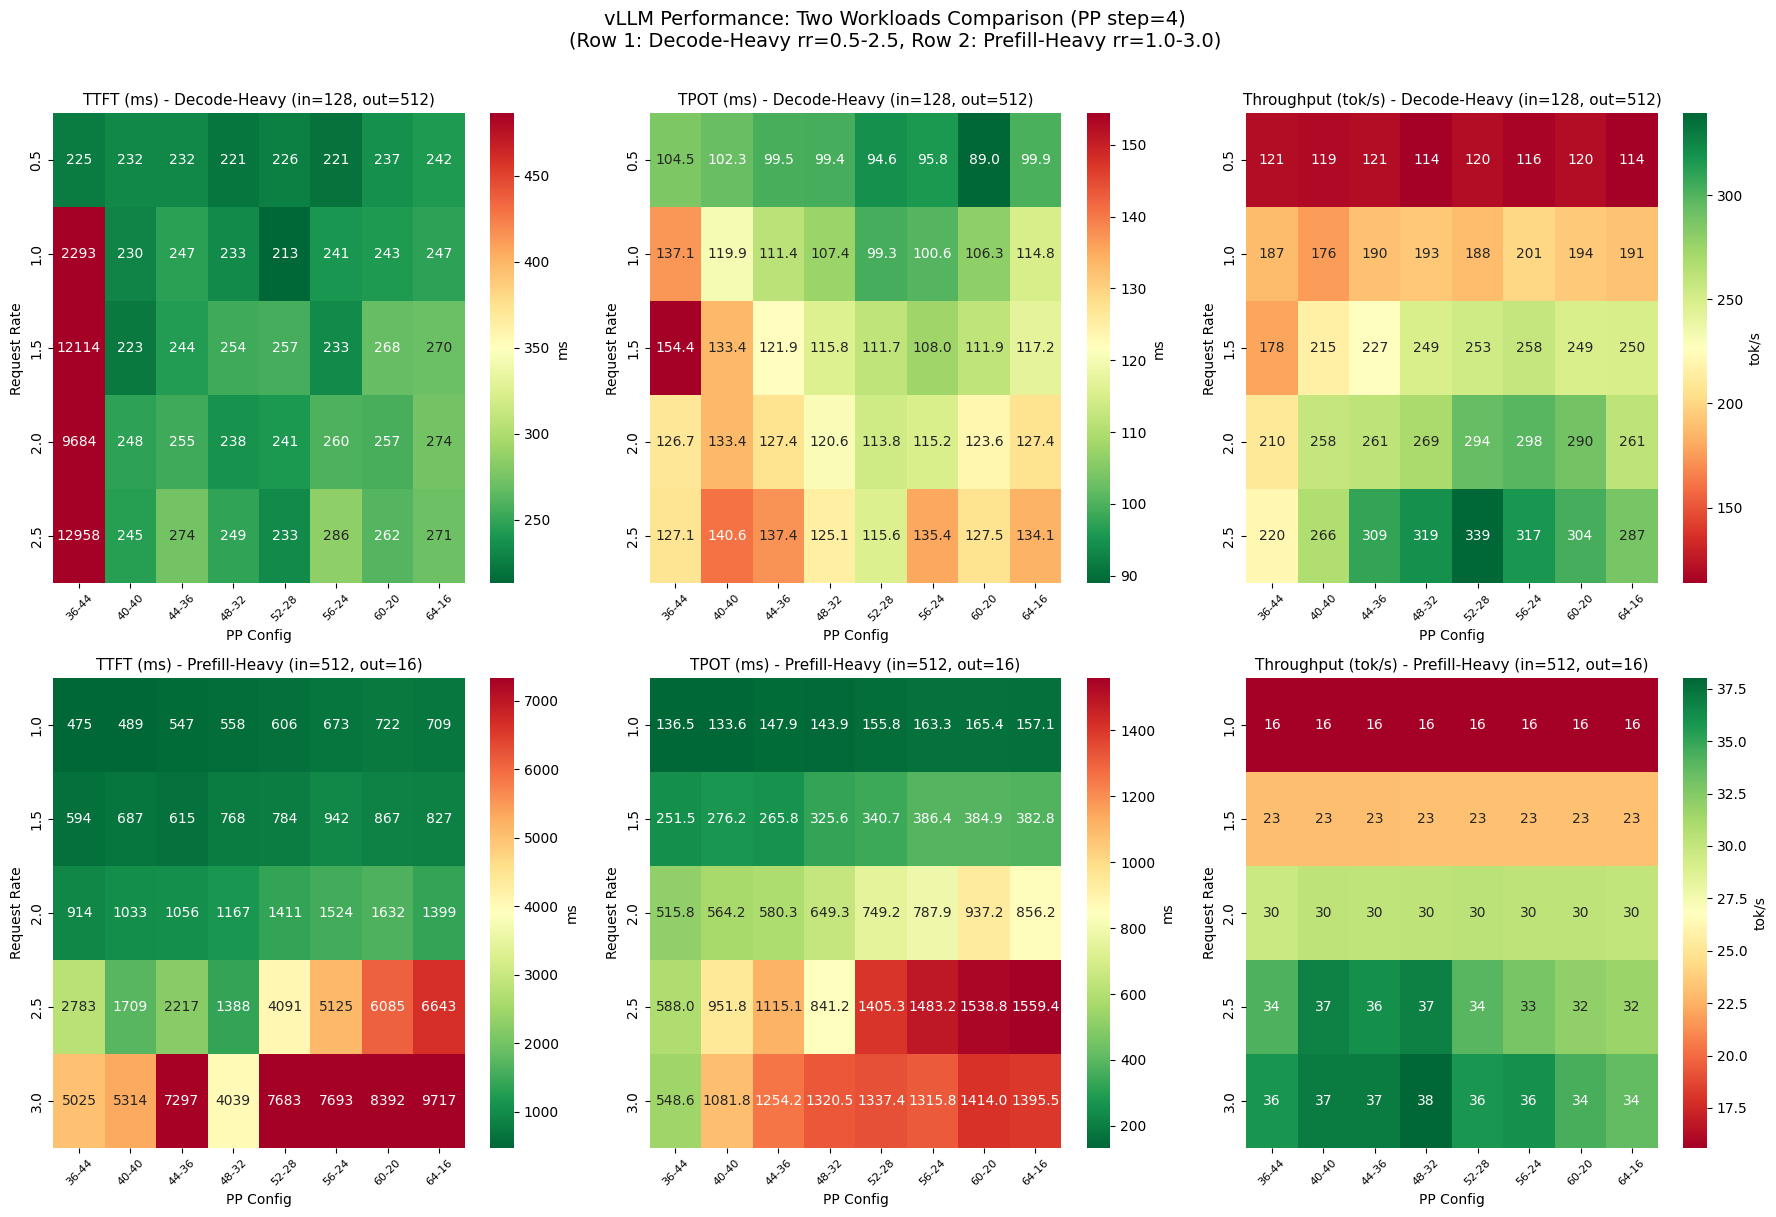

In [20]:
# 配置变量
PP_STEP = 4  # 每隔几个layer显示一个config (可选: 2, 3 或 4)

# 根据step筛选pp_configs (从36开始)
def filter_pp_configs(configs, step):
    """从36-44开始，每隔step个layer选择一个config"""
    result = []
    for pp in configs:
        prefill = int(pp.split('-')[0])
        # 从36开始，每隔step个选一个
        if (prefill - 36) % step == 0:
            result.append(pp)
    return result

pp_configs_filtered = filter_pp_configs(pp_configs_all, PP_STEP)
print(f"PP_STEP = {PP_STEP}")
print(f"筛选后的PP Configs ({len(pp_configs_filtered)}个): {pp_configs_filtered}")

# 根据pp_configs数量动态调整图大小和字体
n_configs = len(pp_configs_filtered)
fig_width = max(18, n_configs * 1.5)  # 每个config至少1.5英寸宽
fig_height = max(10, 12 if n_configs <= 8 else 14)
annot_fontsize = 10 if n_configs <= 8 else (8 if n_configs <= 12 else 6)
fmt_ttft = '.0f' if n_configs <= 10 else '.0f'
fmt_tpot = '.1f' if n_configs <= 10 else '.0f'
fmt_thru = '.0f'

print(f"图大小: {fig_width}x{fig_height}, 标注字体: {annot_fontsize}")

# 定义每个workload显示的request rate范围
workload_rr_range = {
    'in128_out512': [0.5, 1.0, 1.5, 2.0, 2.5],  # Decode-Heavy: 0.5 - 2.5
    'in512_out16': [1.0, 1.5, 2.0, 2.5, 3.0]     # Prefill-Heavy: 1.0 - 3.0
}

# 绘制3X2热力图：每行一个workload，每列一个metric
fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height))

# 定义workload友好名称
workload_names = {
    'in128_out512': 'Decode-Heavy (in=128, out=512)',
    'in512_out16': 'Prefill-Heavy (in=512, out=16)'
}

for row_idx, workload in enumerate(workloads):
    df_w = df_all[df_all['workload'] == workload]
    rr_range = workload_rr_range.get(workload, rr_all)
    
    # 创建pivot tables
    ttft_pv = df_w.pivot_table(values='ttft', index='request_rate', columns='pp_config', aggfunc='mean')
    tpot_pv = df_w.pivot_table(values='tpot', index='request_rate', columns='pp_config', aggfunc='mean')
    thru_pv = df_w.pivot_table(values='throughput', index='request_rate', columns='pp_config', aggfunc='mean')
    
    # 重新排列：只显示筛选后的pp_configs和对应的rr_range
    ttft_pv = ttft_pv.reindex(columns=pp_configs_filtered, index=rr_range)
    tpot_pv = tpot_pv.reindex(columns=pp_configs_filtered, index=rr_range)
    thru_pv = thru_pv.reindex(columns=pp_configs_filtered, index=rr_range)
    
    workload_label = workload_names.get(workload, workload)
    
    # 计算每行TTFT的合理vmax（使用90%分位数，避免极端值影响颜色分布）
    ttft_values = ttft_pv.values.flatten()
    ttft_values = ttft_values[~np.isnan(ttft_values)]
    ttft_vmax = np.percentile(ttft_values, 90) if len(ttft_values) > 0 else None
    ttft_vmin = ttft_values.min() if len(ttft_values) > 0 else None
    
    # TTFT 热力图 - 使用限制的颜色范围
    sns.heatmap(ttft_pv, annot=True, fmt=fmt_ttft, cmap='RdYlGn_r', ax=axes[row_idx, 0],
                cbar_kws={'label': 'ms'}, annot_kws={'size': annot_fontsize},
                vmin=ttft_vmin, vmax=ttft_vmax)
    axes[row_idx, 0].set_title(f'TTFT (ms) - {workload_label}', fontsize=11)
    axes[row_idx, 0].set_xlabel('PP Config', fontsize=10)
    axes[row_idx, 0].set_ylabel('Request Rate', fontsize=10)
    axes[row_idx, 0].tick_params(axis='x', rotation=45, labelsize=8)
    
    # TPOT 热力图
    sns.heatmap(tpot_pv, annot=True, fmt=fmt_tpot, cmap='RdYlGn_r', ax=axes[row_idx, 1],
                cbar_kws={'label': 'ms'}, annot_kws={'size': annot_fontsize})
    axes[row_idx, 1].set_title(f'TPOT (ms) - {workload_label}', fontsize=11)
    axes[row_idx, 1].set_xlabel('PP Config', fontsize=10)
    axes[row_idx, 1].set_ylabel('Request Rate', fontsize=10)
    axes[row_idx, 1].tick_params(axis='x', rotation=45, labelsize=8)
    
    # Throughput 热力图
    sns.heatmap(thru_pv, annot=True, fmt=fmt_thru, cmap='RdYlGn', ax=axes[row_idx, 2],
                cbar_kws={'label': 'tok/s'}, annot_kws={'size': annot_fontsize})
    axes[row_idx, 2].set_title(f'Throughput (tok/s) - {workload_label}', fontsize=11)
    axes[row_idx, 2].set_xlabel('PP Config', fontsize=10)
    axes[row_idx, 2].set_ylabel('Request Rate', fontsize=10)
    axes[row_idx, 2].tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle(f'vLLM Performance: Two Workloads Comparison (PP step={PP_STEP})\n(Row 1: Decode-Heavy rr=0.5-2.5, Row 2: Prefill-Heavy rr=1.0-3.0)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/workload_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()